Imports & Settings

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
warnings.filterwarnings("ignore")

 change these if needed

In [2]:
DATA_PATH = "data/logical_student_dataset_1000.csv"   # your CSV path (change if different)
TARGET_COL = "experties_suggest_career"       # target column name (as you used)
RANDOM_STATE = 42

Start: load dataset

In [3]:
print("Loading:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

Loading: data/logical_student_dataset_1000.csv
Shape: (1000, 13)


,gender,languages_selected,Education Level,major/ field of study,cgpa,experties_major_gpa,experties_suggest_career,current_year,current_semester,mind_stress_management,learning_style,student_expectation,internship_experience
0,Male,"English, Sinhala",Bachelor's degree,Software Engineering,2.63,2.74,QA Engineer,3.0,2.0,Prefer Structured Environments,Visual,Quality Assurance Engineer,Yes
1,Female,"Tamil, Sinhala",Bachelor's degree,Cyber Security,2.10,3.04,Cyber Security Analyst,3.0,1.0,Excellent,Auditory,Quality Assurance Engineer,No
2,Male,"Sinhala, Tamil",Bachelor's degree,Computer Science,2.02,2.14,Systems Analyst,2.0,1.0,Moderate,Kinesthetic,Systems Analyst,No
3,Male,"Tamil, English",Bachelor's degree,Computer Science,3.11,2.36,Systems Analyst,2.0,1.0,Moderate,Kinesthetic,Security Engineer,No
4,Male,"Sinhala, English",Bachelor's degree,Cyber Security,3.71,3.91,Cyber Security Analyst,4.0,1.0,Excellent,Kinesthetic,DevOps Engineer,No


Quick EDA / sanity checks

In [4]:
print("\n--- Data types and missing values ---")
print(df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())


--- Data types and missing values ---
gender                       object
languages_selected           object
Education Level              object
major/ field of study        object
cgpa                        float64
experties_major_gpa         float64
experties_suggest_career     object
current_year                float64
current_semester            float64
mind_stress_management       object
learning_style               object
student_expectation          object
internship_experience        object
dtype: object

Missing values per column:
 gender                      200
languages_selected          200
Education Level             200
major/ field of study         0
cgpa                          0
experties_major_gpa         200
experties_suggest_career      0
current_year                200
current_semester            200
mind_stress_management      200
learning_style              200
student_expectation         200
internship_experience       200
dtype: int64


In [5]:
print("\n--- Target distribution ---")
if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in dataset columns: {list(df.columns)}")

print(df[TARGET_COL].value_counts())
print(df[TARGET_COL].value_counts(normalize=True))


--- Target distribution ---
experties_suggest_career
Network Engineer          114
Software Engineer         109
Systems Analyst           107
Cloud Engineer            100
DevOps Engineer            99
QA Engineer                98
ML Engineer                98
Cyber Security Analyst     93
Data Analyst               91
AI Engineer                91
Name: count, dtype: int64
experties_suggest_career
Network Engineer          0.114
Software Engineer         0.109
Systems Analyst           0.107
Cloud Engineer            0.100
DevOps Engineer           0.099
QA Engineer               0.098
ML Engineer               0.098
Cyber Security Analyst    0.093
Data Analyst              0.091
AI Engineer               0.091
Name: proportion, dtype: float64


Visual: class balance

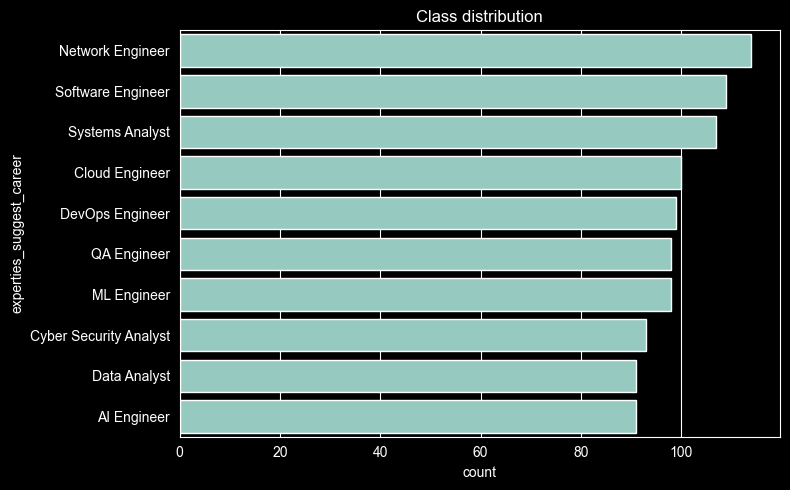

In [6]:
plt.figure(figsize=(8,5))
sns.countplot(y=TARGET_COL, data=df, order=df[TARGET_COL].value_counts().index)
plt.title("Class distribution")
plt.tight_layout()
plt.show()

More EDA: numeric distributions & correlation

In [7]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object","category"]).columns.tolist()
if TARGET_COL in num_cols: num_cols.remove(TARGET_COL)
if TARGET_COL in cat_cols: cat_cols.remove(TARGET_COL)

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

if len(num_cols) > 0:
    display(df[num_cols].describe().T)


Numeric columns: ['cgpa', 'experties_major_gpa', 'current_year', 'current_semester']
Categorical columns: ['gender', 'languages_selected', 'Education Level', 'major/ field of study', 'mind_stress_management', 'learning_style', 'student_expectation', 'internship_experience']


,count,mean,std,min,25%,50%,75%,max
cgpa,1000.0,3.014690,0.556649,2.0,2.55,3.00,3.48,3.99
experties_major_gpa,800.0,2.983025,0.563912,2.0,2.51,2.97,3.47,4.00
current_year,800.0,2.542500,1.123509,1.0,2.00,3.00,4.00,4.00
current_semester,800.0,1.518750,0.499961,1.0,1.00,2.00,2.00,2.00


# Histogram for numeric columns

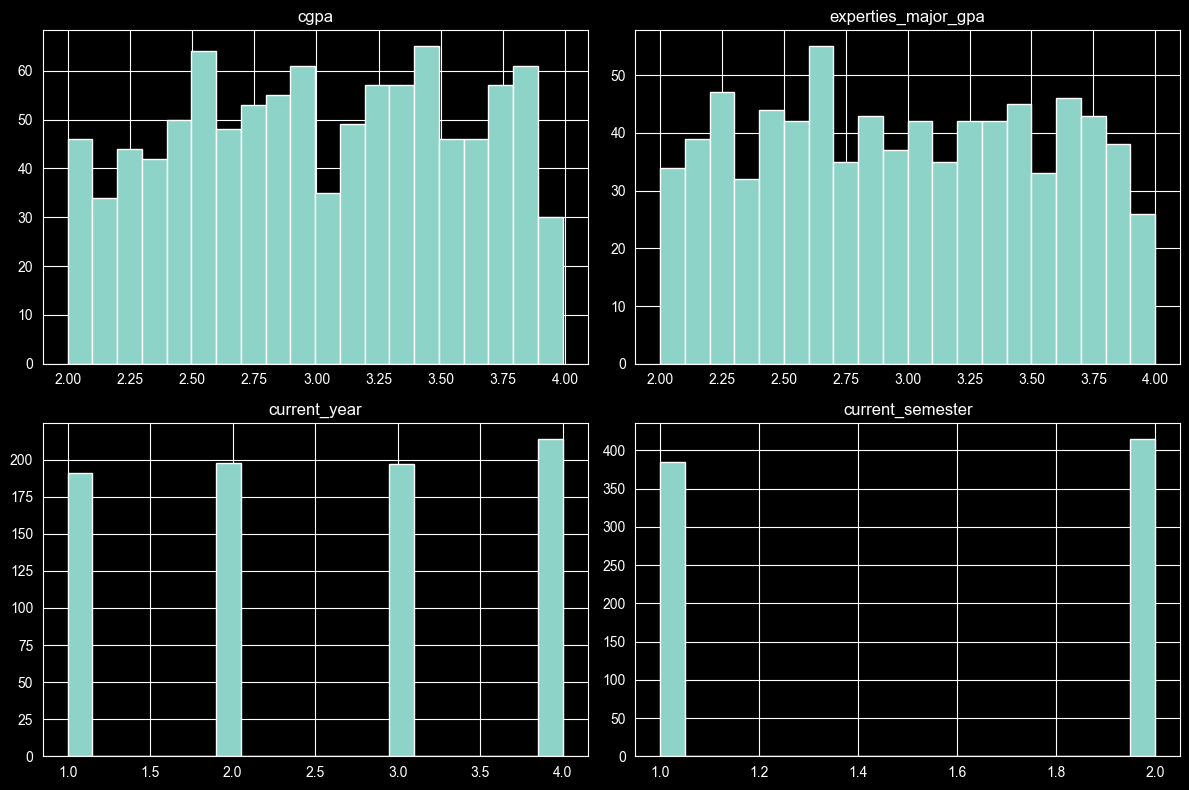

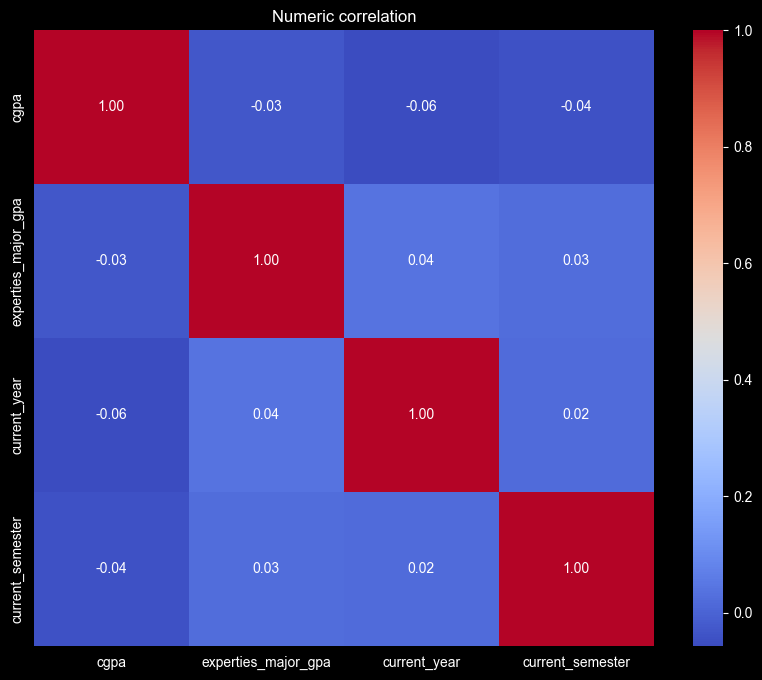

In [8]:
df[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric)
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Numeric correlation")
plt.show()


Handle missing values (simple strategy)

In [9]:
for c in df.columns:
    if df[c].dtype == "object":
        df[c].fillna(df[c].mode()[0] if not df[c].mode().empty else "missing", inplace=True)
    else:
        df[c].fillna(df[c].median(), inplace=True)

print("Missing values after fill:", df.isnull().sum().sum())


Missing values after fill: 0


Prepare X, y and encode target

In [10]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(str)   # ensure string labels

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Classes:", list(label_encoder.classes_))


Classes: ['AI Engineer', 'Cloud Engineer', 'Cyber Security Analyst', 'Data Analyst', 'DevOps Engineer', 'ML Engineer', 'Network Engineer', 'QA Engineer', 'Software Engineer', 'Systems Analyst']


Check class balance numerically

In [11]:
class_counts = pd.Series(y_encoded).value_counts().sort_index()
print("Encoded class counts:\n", class_counts)


Encoded class counts:
 0     91
1    100
2     93
3     91
4     99
5     98
6    114
7     98
8    109
9    107
Name: count, dtype: int64


Train/test split (stratified)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded)
print("Train / Test sizes:", X_train.shape, X_test.shape)

Train / Test sizes: (800, 12) (200, 12)


Preprocessing: detect numeric and categorical columns from X_train

In [13]:
numeric_features = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object","category", "bool"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['cgpa', 'experties_major_gpa', 'current_year', 'current_semester']
Categorical: ['gender', 'languages_selected', 'Education Level', 'major/ field of study', 'mind_stress_management', 'learning_style', 'student_expectation', 'internship_experience']


 Define column transformer

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="drop"
)


Build model pipelines to compare (SMOTE helps if imbalance exists)

In [15]:
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE)
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=RANDOM_STATE)
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
svc = SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE)

pipelines = {
    "RF": ImbPipeline([("pre", preprocessor), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", rf)]),
    "XGB": ImbPipeline([("pre", preprocessor), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", xgb_clf)]),
    "LogReg": ImbPipeline([("pre", preprocessor), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", logreg)]),
    "SVC": ImbPipeline([("pre", preprocessor), ("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", svc)])
}

Quick cross-validation to compare models (stratified k-fold)

In [16]:
print("\n--- Cross-validation (3-fold) mean accuracy ---")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring="accuracy", n_jobs=-1)
    print(f"{name}: mean={scores.mean():.4f} std={scores.std():.4f}")


--- Cross-validation (3-fold) mean accuracy ---
RF: mean=0.6238 std=0.0138
XGB: mean=0.6337 std=0.0307
LogReg: mean=0.5037 std=0.0226
SVC: mean=0.5438 std=0.0153


Fit the best candidate (pick one — start with XGBoost or RF)

In [17]:
best_name = "XGB"   # choose XGB or RF depending on cv results
best_pipe = pipelines[best_name]
print(f"\nFitting chosen model: {best_name}")
best_pipe.fit(X_train, y_train)


Fitting chosen model: XGB


,steps,"[('pre', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given st

Evaluate on train and test

In [20]:
y_train_pred = best_pipe.predict(X_train)
y_test_pred = best_pipe.predict(X_test)

In [21]:
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print("Difference (train - test):", train_acc - test_acc)
print("\nClassification report (test):")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))


Train accuracy: 0.9812
Test accuracy:  0.6900
Difference (train - test): 0.29125

Classification report (test):
                        precision    recall  f1-score   support

           AI Engineer       0.75      0.83      0.79        18
        Cloud Engineer       0.79      0.75      0.77        20
Cyber Security Analyst       1.00      1.00      1.00        19
          Data Analyst       0.81      0.72      0.76        18
       DevOps Engineer       0.61      0.70      0.65        20
           ML Engineer       0.45      0.68      0.54        19
      Network Engineer       0.79      0.83      0.81        23
           QA Engineer       0.65      0.55      0.59        20
     Software Engineer       0.52      0.50      0.51        22
       Systems Analyst       0.67      0.38      0.48        21

              accuracy                           0.69       200
             macro avg       0.70      0.69      0.69       200
          weighted avg       0.70      0.69      0.69 

Confusion matrix

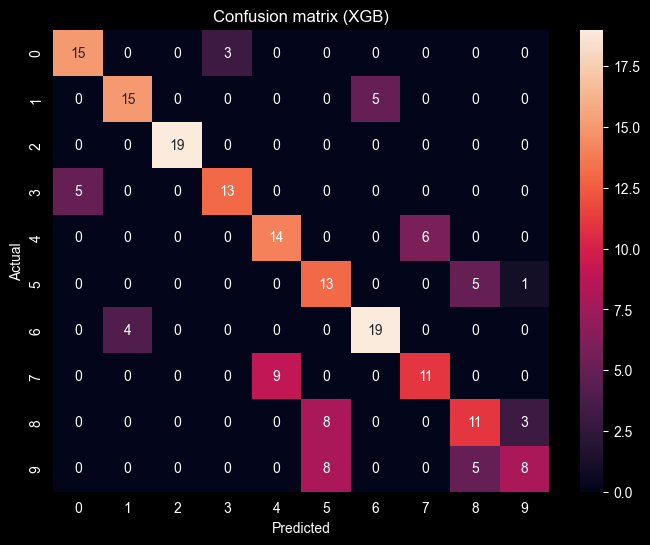

In [22]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title(f"Confusion matrix ({best_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Learning curve to inspect under/overfitting

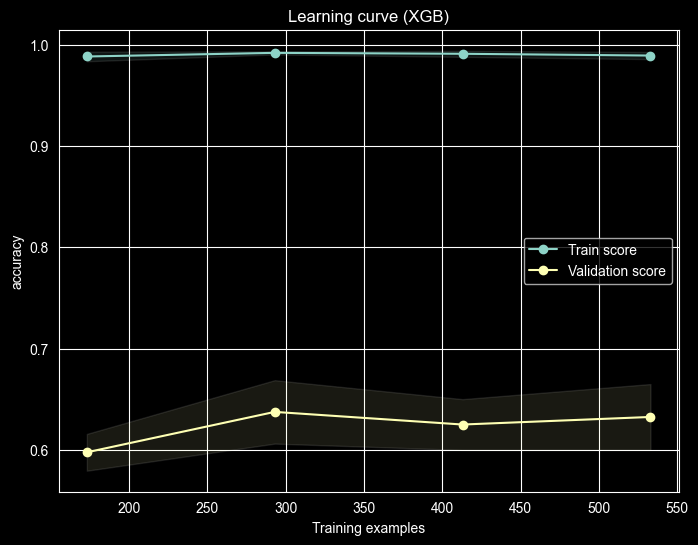


Plotting learning curve (this may take some time)...


In [23]:
def plot_learning_curve(estimator, X, y, title="Learning curve", cv=skf, scoring="accuracy", n_jobs=-1):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=cv, scoring=scoring, n_jobs=n_jobs, train_sizes=np.linspace(0.1,1.0,5), random_state=RANDOM_STATE)
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', label="Train score")
    plt.plot(train_sizes, val_mean, 'o-', label="Validation score")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(True)
    plt.show()
    print("\nPlotting learning curve (this may take some time)...")
plot_learning_curve(best_pipe, X_train, y_train, title=f"Learning curve ({best_name})")

overfitting (train >> test)

In [24]:
param_dist = {
    "clf__n_estimators": [50, 100, 200, 400],
    "clf__max_depth": [3, 5, 7, 9, None],
    "clf__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clf__subsample": [0.6, 0.8, 1.0],
    "clf__colsample_bytree": [0.5, 0.7, 1.0],
    "clf__reg_alpha": [0, 0.1, 0.5, 1.0],
    "clf__reg_lambda": [1, 2, 5]
}

In [25]:
search = RandomizedSearchCV(best_pipe, param_distributions=param_dist, n_iter=25, cv=skf, scoring="accuracy", n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
print("Running RandomizedSearchCV (this can take a while)...")
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

Running RandomizedSearchCV (this can take a while)...
Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params: {'clf__subsample': 0.6, 'clf__reg_lambda': 2, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 200, 'clf__max_depth': None, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 1.0}
Best CV score: 0.6587254653487652


Re-evaluate best found model

In [26]:
best_model = search.best_estimator_
y_test_pred2 = best_model.predict(X_test)
print("Test accuracy after tuning:", accuracy_score(y_test, y_test_pred2))
print(classification_report(y_test, y_test_pred2, target_names=label_encoder.classes_))

Test accuracy after tuning: 0.69
                        precision    recall  f1-score   support

           AI Engineer       1.00      0.72      0.84        18
        Cloud Engineer       0.76      0.65      0.70        20
Cyber Security Analyst       1.00      1.00      1.00        19
          Data Analyst       0.78      1.00      0.88        18
       DevOps Engineer       0.62      0.50      0.56        20
           ML Engineer       0.45      0.68      0.54        19
      Network Engineer       0.73      0.83      0.78        23
           QA Engineer       0.58      0.70      0.64        20
     Software Engineer       0.55      0.50      0.52        22
       Systems Analyst       0.62      0.38      0.47        21

              accuracy                           0.69       200
             macro avg       0.71      0.70      0.69       200
          weighted avg       0.70      0.69      0.69       200



Feature importance

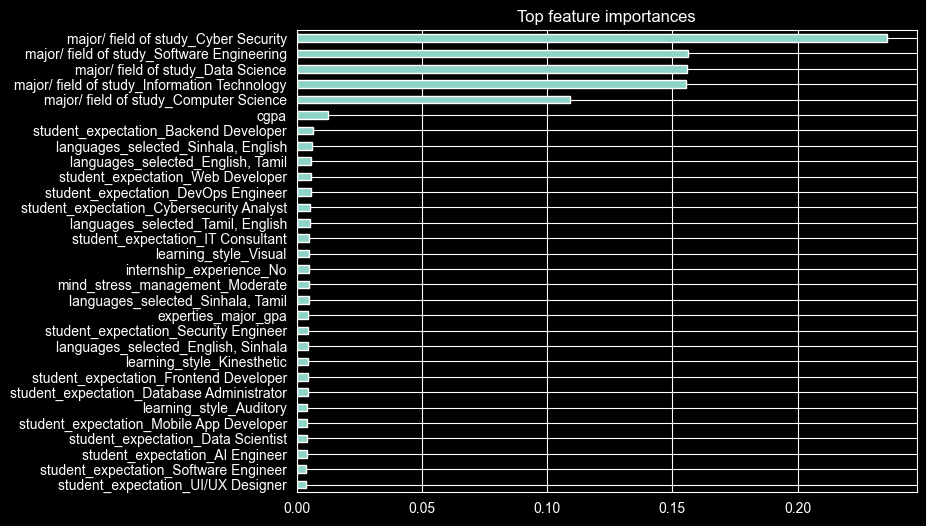

In [27]:
try:
    # extract preprocessor and classifier
    pre = best_model.named_steps['pre']
    clf = best_model.named_steps['clf']
    # get feature names
    cat_enc = pre.named_transformers_['cat']
    if hasattr(cat_enc, "get_feature_names_out"):
        cat_names = list(cat_enc.get_feature_names_out(categorical_features))
    else:
        cat_names = []
    feat_names = list(numeric_features) + cat_names

    if hasattr(clf, "feature_importances_"):
        importances = clf.feature_importances_
        fi = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(30)
        plt.figure(figsize=(8,6))
        fi.plot(kind="barh")
        plt.gca().invert_yaxis()
        plt.title("Top feature importances")
        plt.show()
except Exception as e:
    print("Could not compute feature importances:", e)

Save the final pipeline and label encoder

In [40]:
import os
import joblib
from datetime import datetime

# Create folder if not exists
os.makedirs("../models", exist_ok=True)

print("🔹 Training best model on FULL dataset...")
best_clf.fit(X, y_encoded)

# Save prediction model
joblib.dump(best_clf, "../models/career_prediction_model.joblib")

# Save label encoder
joblib.dump(label_enc, "../models/career_label_encoder.joblib")

# Save metadata
metadata = {
    "model_name": "Career Prediction Model",
    "final_model": best_model_name,
    "algorithm": type(best_clf).__name__,
    "top1_accuracy": float(final_accuracy),
    "top3_accuracy": float(top3_final),
    "features": feature_cols,
    "target_column": "career_label",
    "training_samples": len(X),
    "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "version": "1.0"
}

joblib.dump(metadata, "../models/model_metadata.joblib")

print("\n✅ Model exported successfully!")
print("Saved files:")
print(" - ../models/career_prediction_model.joblib")
print(" - ../models/career_label_encoder.joblib")
print(" - ../models/model_metadata.joblib")

Saved: career_model_pipeline.joblib and label_encoder.joblib


Predict for a new student

In [36]:
new_student = pd.DataFrame([{
    "cgpa": 3.6,
    "experties_major_gpa": 3.7,
    "student_Programming_learned": "Python,Java",
    "student_Databases_Tools": "MySQL",
    "internship_experience": "Yes",
    "real_world_projects_completed": 5
}])

Reindex / add missing columns with defaults so pipeline won't fail

In [37]:
for c in X.columns:
    if c not in new_student.columns:
        new_student[c] = X[c].mode()[0] if X[c].dtype == "object" else X[c].median()

new_student = new_student[X.columns]  # ensure same order
pred_code = best_model.predict(new_student)
pred_label = label_encoder.inverse_transform(pred_code)
print("Prediction:", pred_label[0])

Prediction: Software Engineer
